# Connection MLP

從 `generate_topology_linking_dataset.ipynb` 生成的資料訓練 MLP，預測兩個種子點是否應該連接。

**Label 定義**:
- `hausdorff_sum == inf` → label=0（路徑偏離 GT，不應連接）
- `hausdorff_sum < inf` → label=1（路徑完全在 GT 內，應連接）

**Features（全部可從圖像萃取，不依賴 GT）**:
- `distance`: 兩種子點的歐氏距離
- `normalized_cost`: A* 每像素成本
- `tortuosity`: path_length / distance
- `mean_intensity`: 路徑上的平均亮度
- `min_intensity`: 路徑上的最暗點
- `std_intensity`: 路徑上的亮度標準差
- `frac_bright`: 路徑上亮度 > 閾值的比例

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
import cv2

import skimage as ski
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from scipy.spatial import KDTree
from skimage.measure import label, regionprops


from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.core.evaluation import (
    GraphPointExtractor,
    extract_graph_points,
    compute_average_hausdorff_distance,
    compute_point_min_distances,
)

## 2. Config

In [2]:
DATASET_DIR = Path('/home/pony/projects/ienf_q/data/datasets')
DATA_DIR    = Path('/home/pony/projects/ienf_q/data_0320')

# Auto-discover all sample IDs that have both CSV and pkl
SAMPLE_IDS = sorted(
    p.stem.removeprefix('dataset_')
    for p in DATASET_DIR.glob('dataset_*.csv')
    if not p.stem.endswith('_paths')
    and (DATASET_DIR / f"{p.stem}_paths.pkl").exists()
)


# Seed graph
SEGMENT_LENGTH = 3

# A* search
SEARCH_RADIUS        = 100
BBOX_PADDING         = 10


PATH_FINDING_BBOX_PADDING = 10
HAUSDORFF_INF_SENTINEL = 10**10
HAUSDORFF_IN_LABEL_TOLERANCE = 10

BRIGHT_THRESHOLD = 128  # for frac_bright feature

print(f"Found {len(SAMPLE_IDS)} sample(s): {SAMPLE_IDS}")

Found 17 sample(s): ['S1140-2_a', 'S1140-2_b', 'S1585-2_a', 'S1585-2_b', 'S1616-2_a', 'S222-2_a', 'S222-2_b', 'S226-2_a', 'S226-2_b', 'S236-2_a', 'S236-2_b', 'S341-2_a', 'S341-2_b', 'S487-2_a', 'S487-2_b', 'S558-2_a', 'S558-2_b']


## 3. 特徵萃取

In [5]:
def extract_path_features(path, orig_img, threshold=128):
    """Extract image-based features along an A* path."""
    pts = np.array(path)
    intensities = orig_img[pts[:, 0], pts[:, 1]].astype(np.float32)

    # Max perpendicular deviation from the straight line connecting endpoints
    start, end = pts[0].astype(float), pts[-1].astype(float)
    line_vec = end - start
    line_len = np.linalg.norm(line_vec)
    if line_len > 0:
        max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))
    else:
        max_deviation = 0.0

    return {
        # Intensity statistics
        'mean_intensity':     float(np.mean(intensities)),
        'max_intensity':      float(np.max(intensities)),
        'min_intensity':      float(np.min(intensities)),
        'median_intensity':   float(np.median(intensities)),
        'std_intensity':      float(np.std(intensities)),
        'intensity_q25':      float(np.percentile(intensities, 25)),
        'intensity_q75':      float(np.percentile(intensities, 75)),
        'frac_bright':        float(np.mean(intensities > threshold)),
        # Endpoint intensity (are seeds on bright tissue?)
        'endpoint_intensity': float((intensities[0] + intensities[-1]) / 2),
        # Path shape
        'max_deviation':      max_deviation,
    }

def compute_path_hausdorff_sum(path: list, gt_kdtree: KDTree) -> float:
    """Sum of min distances from each path point to the nearest GT pixel."""
    path_pts = np.array(path)
    dists, _ = gt_kdtree.query(path_pts)
    return float(np.sum(dists))


def load_and_featurize(sample_id, dataset_dir, data_dir, threshold=128):
    """Load CSV + pkl + image, return feature DataFrame."""
    csv_path = dataset_dir / f'dataset_{sample_id}.csv'
    pkl_path = dataset_dir / f'dataset_{sample_id}_paths.pkl'
    img_path = data_dir / sample_id / 'image.png'

    orig_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    orig_green = cv2.split(orig_bgr)[1]  # BGR → green channel (index 1)
    annotation_img = cv2.imread(
        str(data_dir / sample_id / "annotation.png"), cv2.IMREAD_GRAYSCALE
    )
    label_img = cv2.imread(str(data_dir / sample_id / "label.png"), cv2.IMREAD_GRAYSCALE)

    if annotation_img is None:
        raise FileNotFoundError(f"Cannot read annotation.png in {data_dir / sample_id}")
    if label_img is None:
        raise FileNotFoundError(f"Cannot read label.png in {data_dir / sample_id}")

    h, w = annotation_img.shape

    # Build full-image mask (no mask.png in this dataset)
    mask_path = data_dir / sample_id / "mask.png"
    epidermis_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
        
    orig_img = cv2.imread(str(img_path), cv2.IMREAD_COLOR_RGB)
    orig_img = np.array(orig_img)[:, :, 1]  # green channel
        
    sample_pipeline = SkinAnalysisPipeline()
    sample_pipeline.config.threshold.use_full_roi = False
    final_annotation, roi_image, roi_mask = sample_pipeline.run(
        annotation_img, epidermis_mask, orig_green
    )
    topology_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    seed_graph = topology_builder.build_seed_graph(final_annotation, roi_image)

    for u, v, data in seed_graph.edges(data=True):
        data["weight"] = 1e-5

    topology_points = np.array(list(seed_graph.nodes()))
    kdtree = KDTree(topology_points)

    # 必須與訓練資料完全一致：raw green channel + 指數 8
    cost_map = ((255 - roi_image.astype(np.float64)) / 255.0) ** 8

    seed_map = np.zeros_like(cost_map, dtype=np.uint8)
    for p in topology_points:
        seed_map[p[0], p[1]] = True

    binary = (final_annotation > 0).astype(np.uint8)
    comp_map = label(binary, connectivity=2)

    path_finder = PathFinder(cost_map=cost_map)

    path_lookup = path_finder.find_paths_from_seeds(
        topology_points=topology_points,
        kdtree=kdtree,
        search_radius=SEARCH_RADIUS,
        seed_map=seed_map,
        label_img=comp_map,
    )

    label_binary = label_img > 0
    all_samples = []
    gt_pixels = np.column_stack(np.where(label_img > 0))
    gt_kdtree = KDTree(gt_pixels)
    label_binary = label_img > 0

    gt_builder = TopologyBuilder(segment_length=SEGMENT_LENGTH)
    gt_graph   = gt_builder.build_seed_graph(label_img)
    extractor = GraphPointExtractor(remove_duplicates=True)
    gt_kdtree  = KDTree(extractor.extract_points(gt_graph, include_nodes=False, include_edge_paths=True))

    for (u, v), (path, cost) in path_lookup.items():
        path_pts = np.array(path)
        path_in_label = label_binary[path_pts[:, 0], path_pts[:, 1]]
        hausdorff_sum = compute_path_hausdorff_sum(path, gt_kdtree)
        if (
            not np.all(path_in_label)
            and hausdorff_sum > HAUSDORFF_IN_LABEL_TOLERANCE
        ):
            hausdorff_sum = HAUSDORFF_INF_SENTINEL

        distance = float(np.linalg.norm(np.array(u) - np.array(v)))
        pth_arr = np.array(path)
        # calculate path length as sum of Euclidean distances between consecutive points
        path_length = float(np.sum(np.linalg.norm(np.diff(pth_arr, axis=0), axis=1)))
        normalized_cost = float(cost / max(path_length, 1e-8))

        all_samples.append(
            {
                "pair_id": f"{sample_id}_{u[0]}_{u[1]}_{v[0]}_{v[1]}",
                "image_id": sample_id,
                "seed1_y": u[0],
                "seed1_x": u[1],
                "seed2_y": v[0],
                "seed2_x": v[1],
                "distance": distance,
                "path_length": path_length,
                "path_cost": cost,
                "normalized_cost": normalized_cost,
                "hausdorff_sum": hausdorff_sum,
                "path": path,
                "label": hausdorff_sum < HAUSDORFF_IN_LABEL_TOLERANCE,
                "tortuosity" : path_length / max(distance, 1e-8),
                **extract_path_features(path, roi_image, threshold)
            }
        )

    result = pd.DataFrame(all_samples)
    print(f"{sample_id}: {len(result)} samples  "
          f"(label=1: {result['label'].sum()}, label=0: {(result['label']==0).sum()})")
    return result


print('Functions defined')

Functions defined


In [6]:
all_dfs = [load_and_featurize(sid, DATASET_DIR, DATA_DIR, BRIGHT_THRESHOLD)
           for sid in SAMPLE_IDS]
full_df = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal: {len(full_df)} samples")
print(f"label=1: {full_df['label'].sum()}, label=0: {(full_df['label']==0).sum()}")

/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:104: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)
/tmp/ipykernel_299206/1157535175.py:11: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  max_deviation = float(np.max(np.abs(np.cross(line_vec / line_len, pts - start))))


S1140-2_a: 7061 samples  (label=1: 825, label=0: 6236)
S1140-2_b: 7224 samples  (label=1: 1108, label=0: 6116)
S1585-2_a: 4729 samples  (label=1: 719, label=0: 4010)
S1585-2_b: 6168 samples  (label=1: 689, label=0: 5479)
S1616-2_a: 4444 samples  (label=1: 128, label=0: 4316)
S222-2_a: 9780 samples  (label=1: 63, label=0: 9717)
S222-2_b: 5884 samples  (label=1: 42, label=0: 5842)
S226-2_a: 4986 samples  (label=1: 112, label=0: 4874)
S226-2_b: 4586 samples  (label=1: 69, label=0: 4517)
S236-2_a: 12653 samples  (label=1: 202, label=0: 12451)
S236-2_b: 8357 samples  (label=1: 111, label=0: 8246)
S341-2_a: 11824 samples  (label=1: 274, label=0: 11550)
S341-2_b: 8597 samples  (label=1: 244, label=0: 8353)
S487-2_a: 18232 samples  (label=1: 439, label=0: 17793)
S487-2_b: 11203 samples  (label=1: 331, label=0: 10872)
S558-2_a: 5481 samples  (label=1: 194, label=0: 5287)
S558-2_b: 2912 samples  (label=1: 78, label=0: 2834)

Total: 134121 samples
label=1: 5628, label=0: 128493


In [7]:
# select equal number of positive and negative samples for balanced training
positive_samples = full_df[full_df['label'] == 1]
negative_samples = full_df[full_df['label'] == 0].sample(n=int(len(positive_samples) * 1.5), random_state=42)
balanced_df = pd.concat([positive_samples, negative_samples], ignore_index=True)
print(f"Balanced dataset: {len(balanced_df)} samples")

Balanced dataset: 14070 samples


## 4. 特徵分佈

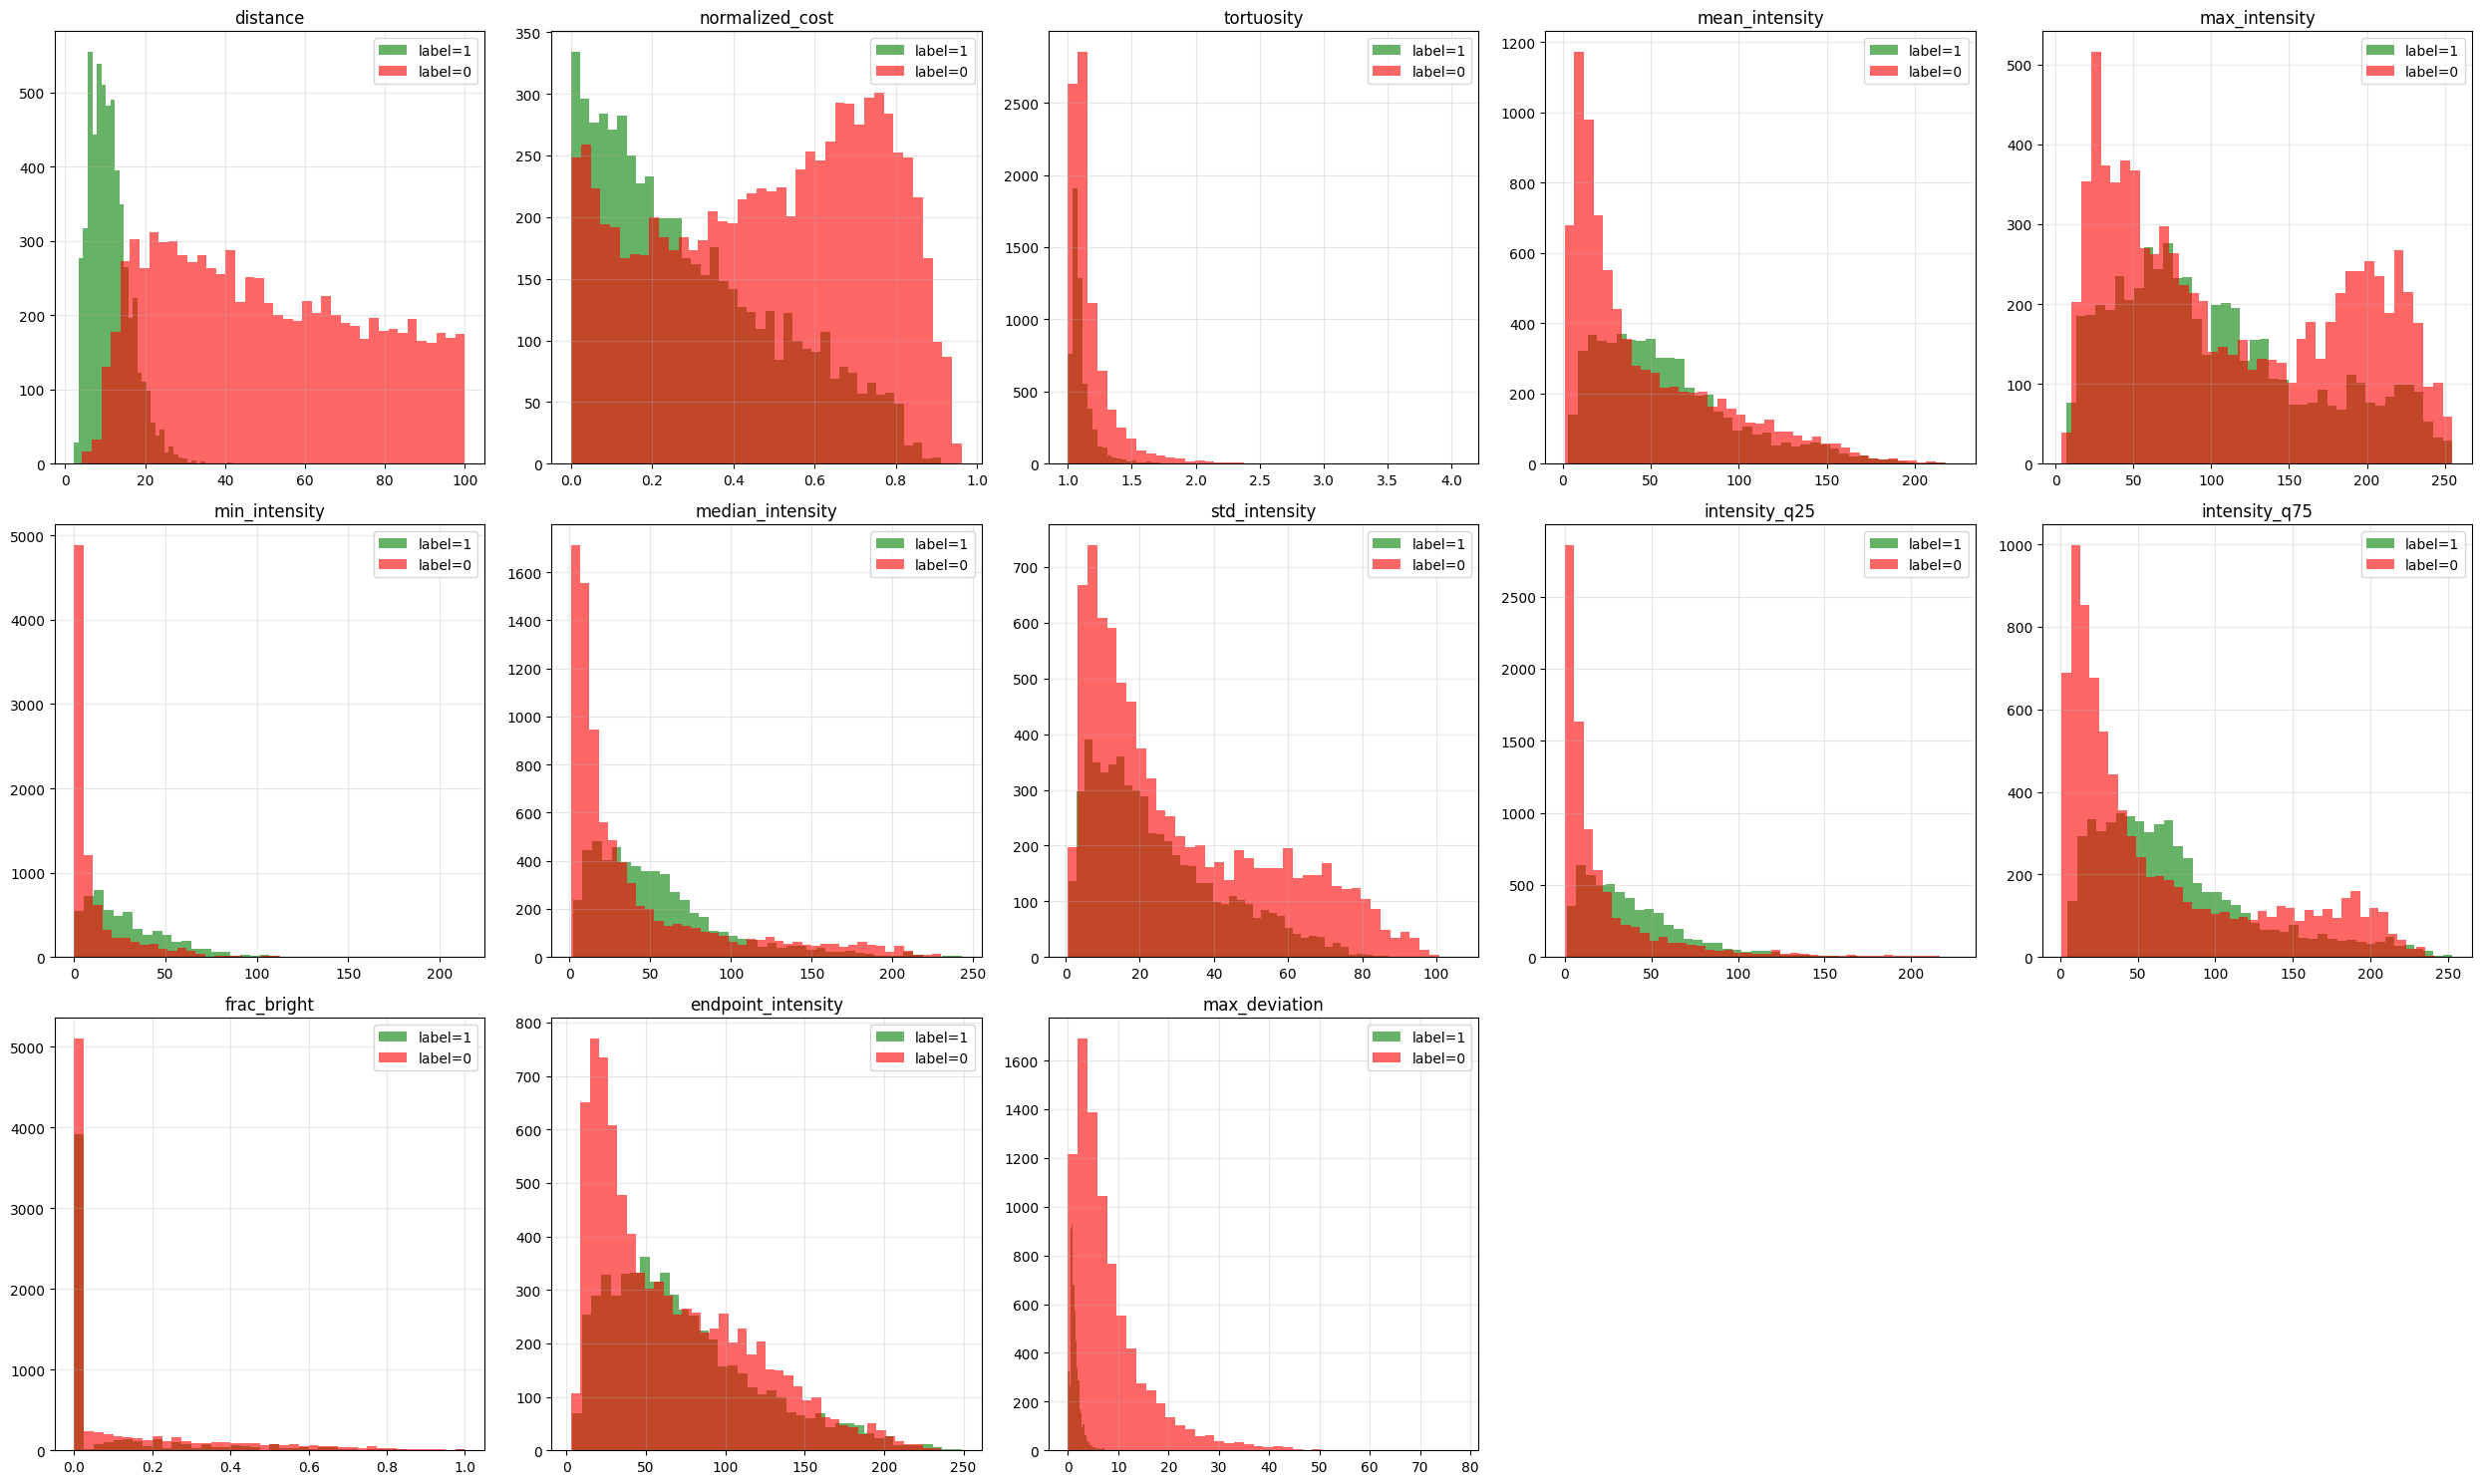

In [8]:
FEATURES = [
    'distance', 'normalized_cost', 'tortuosity',
    'mean_intensity', 'max_intensity', 'min_intensity', 'median_intensity',
    'std_intensity', 'intensity_q25', 'intensity_q75',
    'frac_bright', 'endpoint_intensity', 'max_deviation',
]

fig, axes = plt.subplots(3, 5, figsize=(25, 15))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    balanced_df[balanced_df['label'] == 1][feat].hist(bins=40, alpha=0.6, color='green', label='label=1', ax=ax)
    balanced_df[balanced_df['label'] == 0][feat].hist(bins=40, alpha=0.6, color='red',   label='label=0', ax=ax)
    ax.set_title(feat)
    ax.legend()
    ax.grid(True, alpha=0.3)

for j in range(len(FEATURES), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 5. Train / Test Split

In [9]:
X = balanced_df[FEATURES].values
y = balanced_df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  (pos={y_train.sum()}, neg={(y_train==0).sum()})")
print(f"Test:  {len(X_test)}   (pos={y_test.sum()},  neg={(y_test==0).sum()})")

Train: 11256  (pos=4502, neg=6754)
Test:  2814   (pos=1126,  neg=1688)


## 6. XGBoost 訓練

In [10]:
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-auc:0.95705
[50]	validation_0-auc:0.96696
[100]	validation_0-auc:0.96776
[150]	validation_0-auc:0.96829
[200]	validation_0-auc:0.96863
[250]	validation_0-auc:0.96883
[266]	validation_0-auc:0.96886

Best iteration: 246


/home/pony/projects/ienf_q/.venv/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [10:15:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


## 7. 評估

In [11]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['label=0 (bad)', 'label=1 (good)']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

                precision    recall  f1-score   support

 label=0 (bad)       0.95      0.89      0.92      1688
label=1 (good)       0.85      0.92      0.89      1126

      accuracy                           0.91      2814
     macro avg       0.90      0.91      0.90      2814
  weighted avg       0.91      0.91      0.91      2814

AUC-ROC: 0.9689


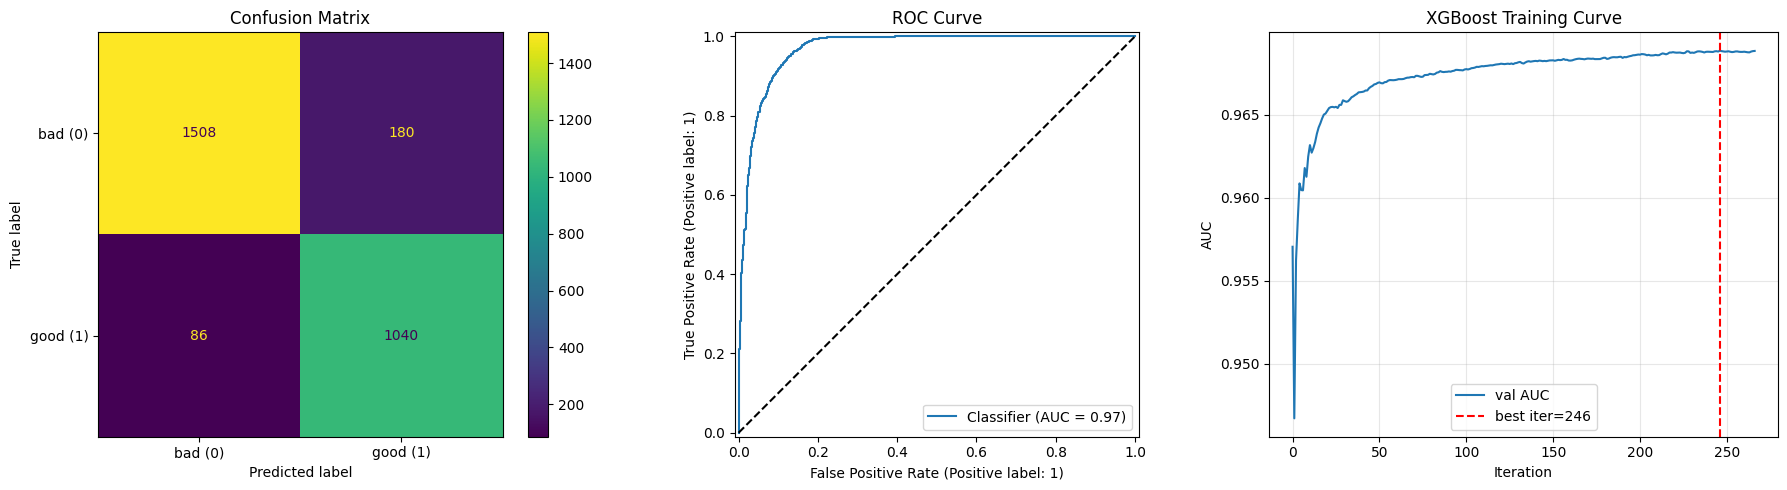

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['bad (0)', 'good (1)'], ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')
axes[1].plot([0, 1], [0, 1], 'k--')

# Training AUC curve
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
axes[2].plot(range(epochs), results['validation_0']['auc'], label='val AUC')
axes[2].axvline(model.best_iteration, color='r', linestyle='--', label=f'best iter={model.best_iteration}')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('AUC')
axes[2].set_title('XGBoost Training Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 特徵重要性

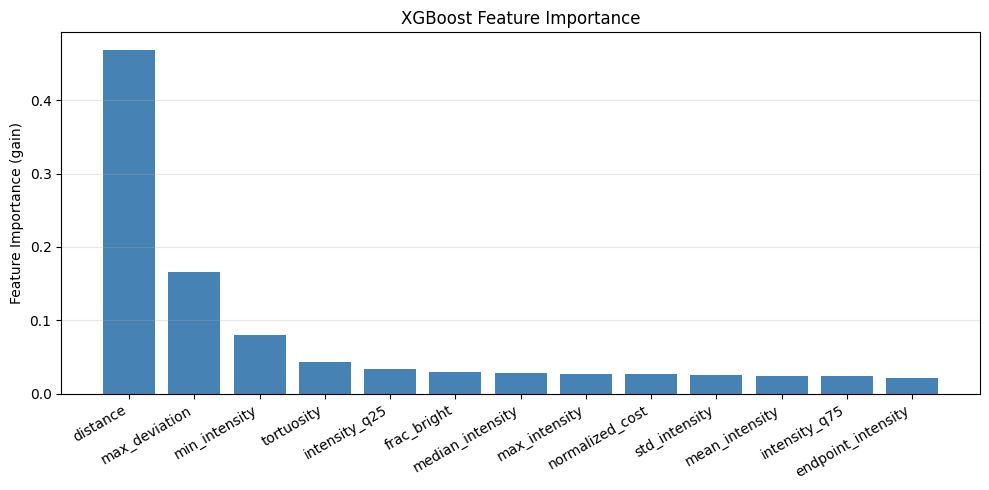

In [13]:
importances = model.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(FEATURES)), importances[order], color='steelblue')
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in order], rotation=30, ha='right')
ax.set_ylabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [14]:
import pickle as _pickle

model_pkl_path = DATASET_DIR / 'xgb_connection_filter.pkl'
with open(model_pkl_path, 'wb') as f:
    _pickle.dump(model, f)
print(f"Model saved (pickle): {model_pkl_path}")

Model saved (pickle): /home/pony/projects/ienf_q/data/datasets/xgb_connection_filter.pkl


## 9. Per-Sample Accuracy

In [15]:
model.save_model(str(DATASET_DIR / 'xgb_connection_filter.json'))

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score

rows = []
for sid, df in zip(SAMPLE_IDS, all_dfs):
    X_s = scaler.transform(df[FEATURES].values)
    y_s = df['label'].values

    y_pred_s  = model.predict(X_s)
    y_proba_s = model.predict_proba(X_s)[:, 1]

    n_pos = int(y_s.sum())
    n_neg = int((y_s == 0).sum())
    acc   = accuracy_score(y_s, y_pred_s)
    auc   = roc_auc_score(y_s, y_proba_s) if n_pos > 0 and n_neg > 0 else float('nan')

    rows.append({
        'sample_id': sid,
        'n_total':   len(y_s),
        'n_pos':     n_pos,
        'n_neg':     n_neg,
        'accuracy':  round(acc, 4),
        'auc_roc':   round(auc, 4),
    })

per_sample_df = pd.DataFrame(rows)
per_sample_df = per_sample_df.sort_values('accuracy', ascending=True).reset_index(drop=True)

print(per_sample_df.to_string(index=False))
print(f"\nMean accuracy : {per_sample_df['accuracy'].mean():.4f}")
print(f"Mean AUC-ROC  : {per_sample_df['auc_roc'].mean():.4f}")

sample_id  n_total  n_pos  n_neg  accuracy  auc_roc
S1585-2_a     4729    719   4010    0.8653   0.9695
 S558-2_a     5481    194   5287    0.8827   0.9596
S1140-2_b     7224   1108   6116    0.8875   0.9774
S1140-2_a     7061    825   6236    0.8946   0.9745
 S341-2_b     8597    244   8353    0.8986   0.9710
 S487-2_b    11203    331  10872    0.9019   0.9733
S1585-2_b     6168    689   5479    0.9052   0.9791
 S558-2_b     2912     78   2834    0.9073   0.9571
 S341-2_a    11824    274  11550    0.9125   0.9701
 S222-2_a     9780     63   9717    0.9170   0.9714
 S236-2_a    12653    202  12451    0.9248   0.9731
 S222-2_b     5884     42   5842    0.9262   0.9737
S1616-2_a     4444    128   4316    0.9284   0.9715
 S487-2_a    18232    439  17793    0.9290   0.9704
 S236-2_b     8357    111   8246    0.9294   0.9752
 S226-2_a     4986    112   4874    0.9328   0.9754
 S226-2_b     4586     69   4517    0.9333   0.9715

Mean accuracy : 0.9104
Mean AUC-ROC  : 0.9714


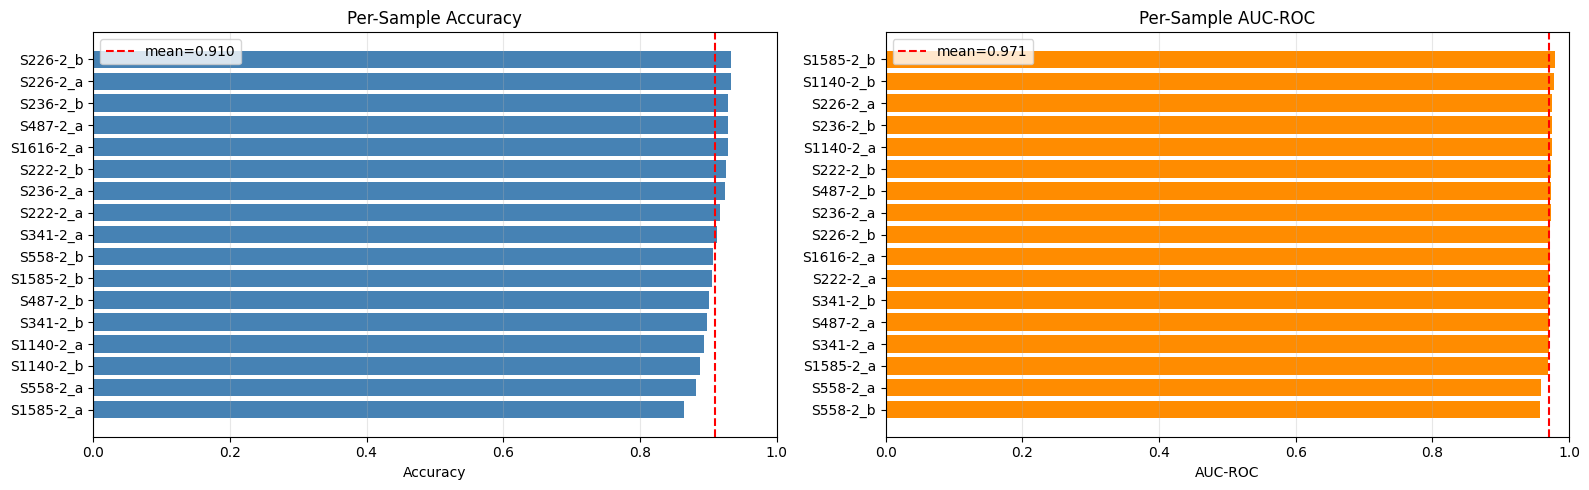

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_df = per_sample_df.sort_values('accuracy')

axes[0].barh(sorted_df['sample_id'], sorted_df['accuracy'], color='steelblue')
axes[0].axvline(per_sample_df['accuracy'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['accuracy'].mean():.3f}")
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Per-Sample Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].set_xlim(0, 1)

sorted_auc = per_sample_df.sort_values('auc_roc')
axes[1].barh(sorted_auc['sample_id'], sorted_auc['auc_roc'], color='darkorange')
axes[1].axvline(per_sample_df['auc_roc'].mean(), color='red', linestyle='--',
                label=f"mean={per_sample_df['auc_roc'].mean():.3f}")
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('Per-Sample AUC-ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 10. 單張樣本視覺化

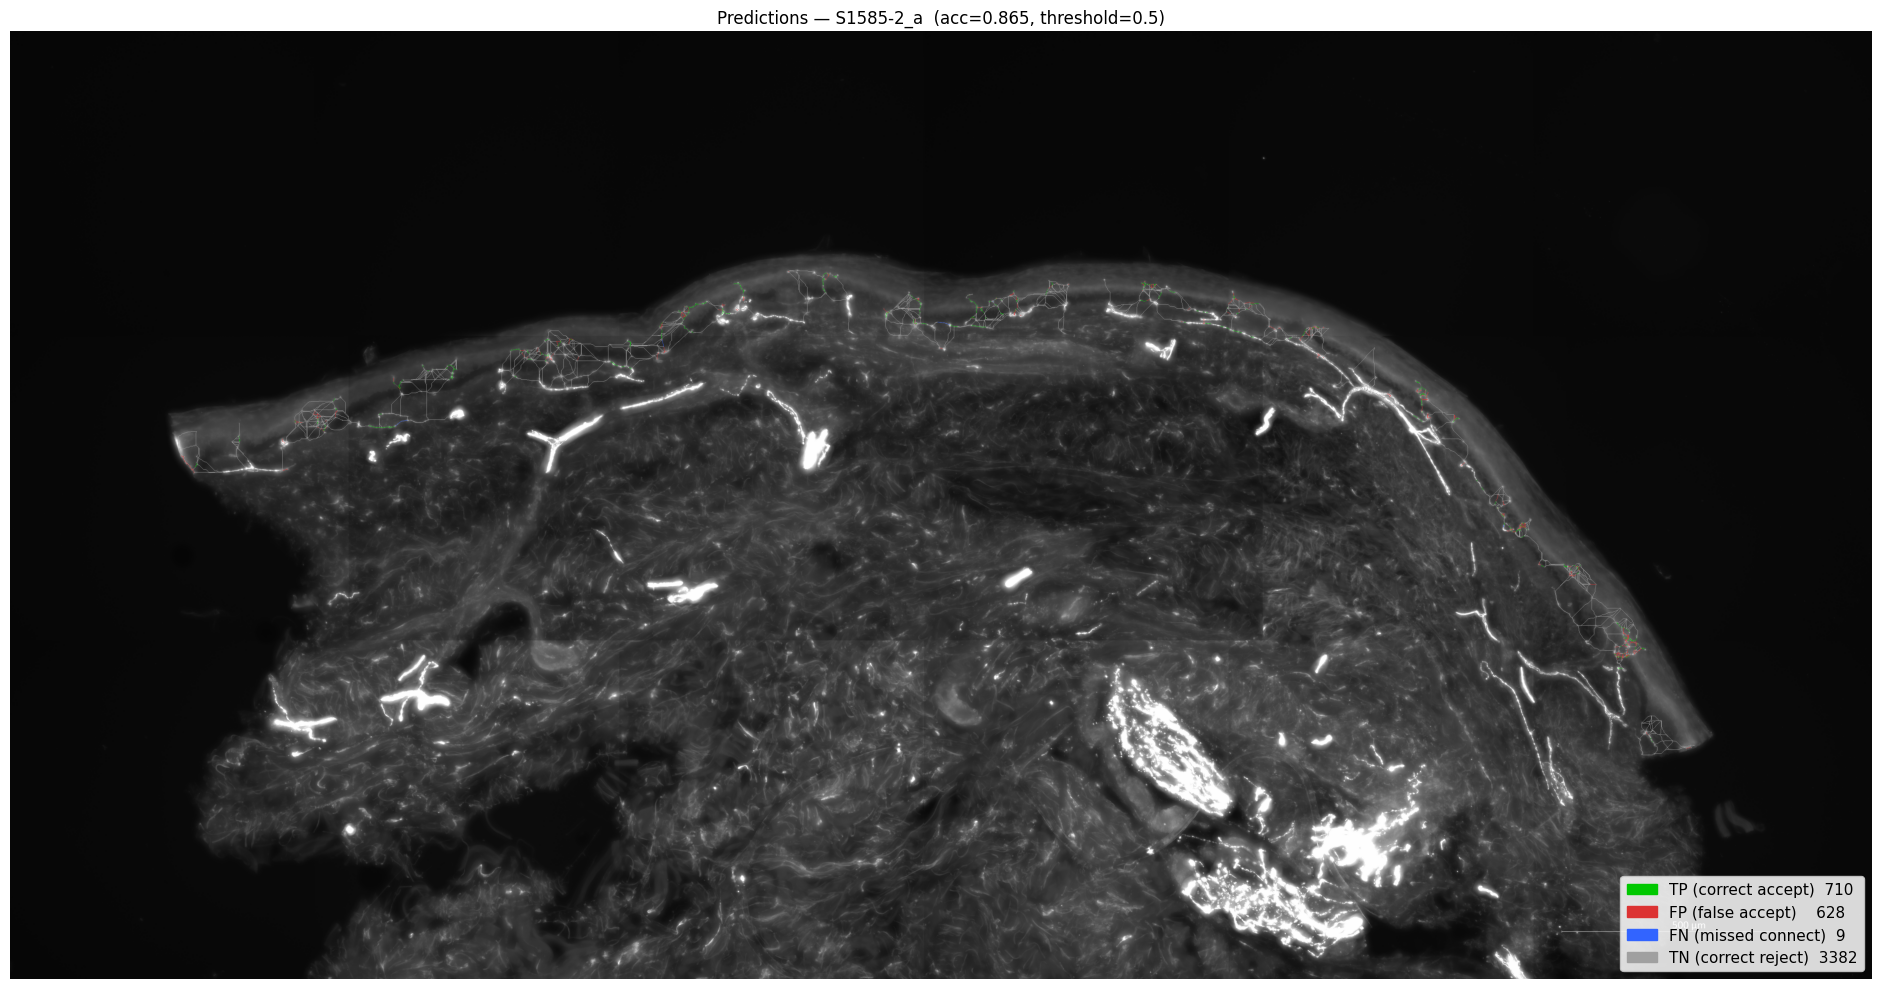

{'TP': 710, 'TN': 3382, 'FP': 628, 'FN': 9}


In [18]:

# ── Config ────────────────────────────────────────────────────────────────────
VIS_SAMPLE_ID  = "S1585-2_a"   # change to any sample id
PROB_THRESHOLD = 0.5             # decision boundary for coloring

vis_df = full_df[full_df['image_id'] == VIS_SAMPLE_ID].reset_index(drop=True)

pkl_path = DATASET_DIR / f'dataset_{VIS_SAMPLE_ID}_paths.pkl'
img_path = DATA_DIR / VIS_SAMPLE_ID / 'image.png'

orig_bgr  = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
orig_green = orig_rgb[:, :, 1]  # green channel for feature extraction

# ── Predict ───────────────────────────────────────────────────────────────────
X_vis  = scaler.transform(vis_df[FEATURES].values)
y_vis  = vis_df['label'].values
proba  = model.predict_proba(X_vis)[:, 1]
pred   = (proba >= PROB_THRESHOLD).astype(int)

# ── Draw paths ────────────────────────────────────────────────────────────────
# TP=green, TN=gray, FP=red, FN=blue
COLOR_TP = (0, 200, 0)
COLOR_TN = (160, 160, 160)
COLOR_FP = (220, 50, 50)
COLOR_FN = (50, 100, 255)

canvas = cv2.cvtColor(orig_green, cv2.COLOR_GRAY2RGB).copy()

id_col = 'pair_id' if 'pair_id' in vis_df.columns else 'sample_id'

counts = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
for row_id, gt, pr in zip(vis_df[id_col], y_vis, pred):
    path = vis_df.loc[vis_df[id_col] == row_id, 'path'].values[0]
    if path is None:
        continue

    if   gt == 1 and pr == 1:  color = COLOR_TP; counts['TP'] += 1
    elif gt == 0 and pr == 0:  color = COLOR_TN; counts['TN'] += 1
    elif gt == 0 and pr == 1:  color = COLOR_FP; counts['FP'] += 1
    else:                      color = COLOR_FN; counts['FN'] += 1

    pts = np.array(path)
    canvas[pts[:, 0], pts[:, 1]] = color

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(22, 10))

ax.imshow(canvas)
legend_patches = [
    Patch(color=np.array(COLOR_TP)/255, label=f'TP (correct accept)  {counts["TP"]}'),
    Patch(color=np.array(COLOR_FP)/255, label=f'FP (false accept)    {counts["FP"]}'),
    Patch(color=np.array(COLOR_FN)/255, label=f'FN (missed connect)  {counts["FN"]}'),
    Patch(color=np.array(COLOR_TN)/255, label=f'TN (correct reject)  {counts["TN"]}'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=11, framealpha=0.85)
acc = (counts['TP'] + counts['TN']) / max(sum(counts.values()), 1)
ax.set_title(f'Predictions — {VIS_SAMPLE_ID}  (acc={acc:.3f}, threshold={PROB_THRESHOLD})')
ax.axis('off')

plt.tight_layout()
plt.show()
print(counts)


In [19]:
import joblib
joblib.dump(scaler, 'scaler.joblib')

['scaler.joblib']